# Association Rule Learning — Groceries Dataset
**Author:** Emmanuel Manzi  
**Assignment:** Unsupervised Learning Method — Association Rule Learning

## Setup

In [3]:
%pip install mlxtend

  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached scikit_learn-1.9.1-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 567.7 kB/s eta 0:00:02
   ----------------------- ---------------- 0.8/1.4 MB 736.1 kB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 736.1 kB/s eta 0:00:01
   


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

%matplotlib inline


## Question 1: Understand the Data
Load the Groceries dataset (basket format: one transaction per row, ragged item lists, no header) and report the number of transactions, number of unique items, and the 10 most frequently purchased items.

In [6]:
DATA_PATH = "groceries.csv"

transactions = []
with open(DATA_PATH, encoding="utf-8") as f:
    for line in f:
        items = [x.strip() for x in line.strip().split(",") if x.strip() != ""]
        if items:
            transactions.append(items)

n_transactions = len(transactions)
all_items = sorted(set(item for t in transactions for item in t))
n_items = len(all_items)

print(f"a. Number of transactions: {n_transactions}")
print(f"b. Number of unique items:  {n_items}")

a. Number of transactions: 9835
b. Number of unique items:  169


In [8]:
# c. Top 10 most frequently purchased items
counts = Counter(item for t in transactions for item in t)
top10 = pd.DataFrame(counts.most_common(10), columns=["item", "count"])
top10["support"] = top10["count"] / n_transactions
top10

,item,count,support
0,whole milk,2513,0.255516
1,other vegetables,1903,0.193493
2,rolls/buns,1809,0.183935
3,soda,1715,0.174377
4,yogurt,1372,0.139502
5,bottled water,1087,0.110524
6,root vegetables,1072,0.108998
7,tropical fruit,1032,0.104931
8,shopping bags,969,0.098526
9,sausage,924,0.093950


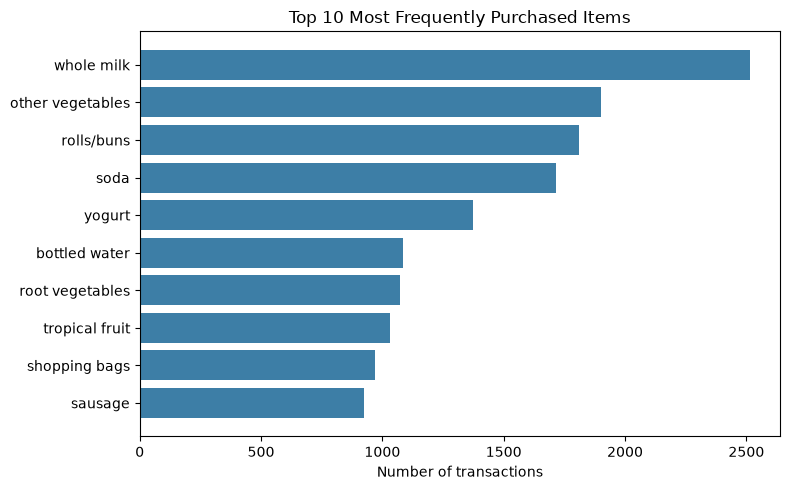

In [9]:
plt.figure(figsize=(8, 5))
plt.barh(top10["item"][::-1], top10["count"][::-1], color="#3d7ea6")
plt.xlabel("Number of transactions")
plt.title("Top 10 Most Frequently Purchased Items")
plt.tight_layout()
plt.savefig("top10_items.png", dpi=150)
plt.show()

## Encode transactions
One-hot encode the transaction list into a boolean DataFrame so `mlxtend` can mine frequent itemsets.

In [10]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.shape

(9835, 169)

## Question 2: Frequent Itemsets
Use the Apriori algorithm (minimum support = 1%) to find frequent itemsets, then filter to itemsets containing two or more products.

In [11]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

multi_itemsets = (
    frequent_itemsets[frequent_itemsets["length"] >= 2]
    .sort_values("support", ascending=False)
    .copy()
)
multi_itemsets_display = multi_itemsets.copy()
multi_itemsets_display["itemsets"] = multi_itemsets_display["itemsets"].apply(lambda x: ", ".join(sorted(x)))
multi_itemsets_display[["itemsets", "support"]].head(15)

,itemsets,support
239,"other vegetables, whole milk",0.074835
267,"rolls/buns, whole milk",0.056634
300,"whole milk, yogurt",0.056024
274,"root vegetables, whole milk",0.048907
229,"other vegetables, root vegetables",0.047382
240,"other vegetables, yogurt",0.043416
228,"other vegetables, rolls/buns",0.042603
294,"tropical fruit, whole milk",0.042298
290,"soda, whole milk",0.040061
264,"rolls/buns, soda",0.038332


**c. Highest-support itemset:** `{other vegetables, whole milk}` — appears in ~7.5% of all transactions.

**d. Interpretation:** Support measures how frequently an itemset occurs across all transactions. A higher support value means a larger share of customers buy that combination, so these are the pairings most worth acting on since they affect the most baskets. Low-support itemsets may still be interesting, but they only apply to a small slice of customers.

## Question 3: Association Rules
Generate association rules from the frequent itemsets (minimum confidence = 20%), keeping single-item consequents for readability, and report antecedent, consequent, support, confidence, and lift for each.

In [13]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.2)
rules = rules[rules["consequents"].apply(lambda x: len(x) == 1)]

rules_out = rules.copy()
rules_out["antecedents"] = rules_out["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules_out["consequents"] = rules_out["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules_out = rules_out[["antecedents", "consequents", "support", "confidence", "lift"]]
rules_out = rules_out.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Total rules generated: {len(rules_out)}")
top10_rules = rules_out.head(10)
top10_rules

Total rules generated: 231


,antecedents,consequents,support,confidence,lift
0,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
1,"other vegetables, yogurt",whipped/sour cream,0.010168,0.234192,3.267062
2,"other vegetables, tropical fruit",root vegetables,0.012303,0.342776,3.144780
3,beef,root vegetables,0.017387,0.331395,3.040367
4,"citrus fruit, root vegetables",other vegetables,0.010371,0.586207,3.029608
5,"root vegetables, tropical fruit",other vegetables,0.012303,0.584541,3.020999
6,"other vegetables, whole milk",root vegetables,0.023183,0.309783,2.842082
7,"curd, whole milk",yogurt,0.010066,0.385214,2.761356
8,"other vegetables, yogurt",root vegetables,0.012913,0.297424,2.728698
9,"other vegetables, yogurt",tropical fruit,0.012303,0.283372,2.700550


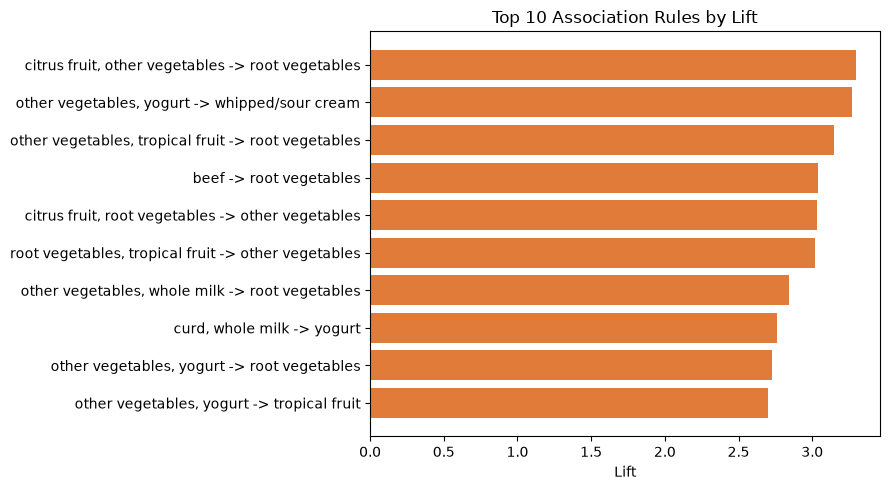

In [14]:
plt.figure(figsize=(9, 5))
labels = [f"{a} -> {c}" for a, c in zip(top10_rules["antecedents"], top10_rules["consequents"])]
plt.barh(labels[::-1], top10_rules["lift"][::-1], color="#e07b39")
plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift")
plt.tight_layout()
plt.savefig("top10_rules_lift.png", dpi=150)
plt.show()

## Question 4: Understanding the Measures

**Rule 1: {citrus fruit, other vegetables} → {root vegetables}**
- *Support (1.04%)*: this combination of all three items appears in about 1 out of every 100 transactions.
- *Confidence (35.9%)*: of customers who buy citrus fruit and other vegetables, about 36% also buy root vegetables.
- *Lift (3.30)*: these customers are about 3.3x more likely to buy root vegetables than a random customer — a strong association.

**Rule 2: {citrus fruit, root vegetables} → {other vegetables}**
- *Support (1.04%)*: appears in about 1% of all transactions.
- *Confidence (58.6%)*: nearly 6 in 10 customers who buy citrus fruit and root vegetables also buy other vegetables — the highest confidence generated.
- *Lift (3.03)*: about 3x more likely than average to also buy other vegetables.

**Rule 3: {other vegetables} → {whole milk}**
- *Support (7.48%)*: the most common pairing in the dataset.
- *Confidence (38.7%)*: almost 39% of customers who buy other vegetables also buy whole milk.
- *Lift (1.51)*: a moderate but still meaningful positive association.

## Question 5: Find Interesting Rules
Identify the rules with the highest confidence, highest lift, and highest support.

In [15]:
highest_conf = rules_out.sort_values("confidence", ascending=False).iloc[0]
highest_lift = rules_out.sort_values("lift", ascending=False).iloc[0]
highest_support = rules_out.sort_values("support", ascending=False).iloc[0]

print("Highest confidence rule:\n", highest_conf, "\n")
print("Highest lift rule:\n", highest_lift, "\n")
print("Highest support rule:\n", highest_support)

Highest confidence rule:
 antecedents    citrus fruit, root vegetables
consequents                 other vegetables
support                             0.010371
confidence                          0.586207
lift                                3.029608
Name: 4, dtype: object 

Highest lift rule:
 antecedents    citrus fruit, other vegetables
consequents                   root vegetables
support                              0.010371
confidence                           0.359155
lift                                 3.295045
Name: 0, dtype: object 

Highest support rule:
 antecedents    other vegetables
consequents          whole milk
support                0.074835
confidence             0.386758
lift                   1.513634
Name: 154, dtype: object


**d. Are these the same rule?** No. The highest-support rule (`{other vegetables} → {whole milk}`) simply reflects that both items are purchased very often overall — its lift (1.51) is comparatively modest. The highest-confidence and highest-lift rules both involve citrus fruit, root vegetables, and other vegetables, describing a narrower but statistically stronger relationship: these items co-occur far more than chance would predict, even though fewer customers buy them. Support reflects popularity; confidence and lift reflect the strength of the relationship.

## Question 6: Interpret a Rule

**Rule: {citrus fruit, root vegetables} → {other vegetables}**

In simple language: customers who purchase citrus fruit and root vegetables also tend to purchase other vegetables. This makes intuitive sense — these are all fresh-produce items, so a customer stocking up on produce for the week tends to pick up several types of vegetables and fruit at once.

This is a **strong** association. The confidence of 58.6% means the rule holds for well over half of the relevant customers, and the lift of 3.03 shows these customers are three times more likely than average to also buy other vegetables. Both measures point in the same direction, confirming the relationship is meaningful rather than coincidental.

## Question 7: Business Application

**a. Products to place close together:** Root vegetables and other vegetables — they show high lift (2.84–3.02 across several rules) and are already part of the same fresh-produce shopping trip.

**b. Possible product bundle:** A "Fresh Produce Basket" bundle of citrus fruit, root vegetables, and other vegetables, since all three appear together far more often than chance would predict.

**c. Recommendation engine example:** When a customer adds root vegetables and citrus fruit to their cart, the system could automatically suggest other vegetables ("customers who bought this also bought..."), since 58.6% of similar customers went on to buy it.

## Question 8: Understanding Association

**a. Does an association rule prove causation?** No. An association rule only shows that two items are statistically likely to appear in the same transaction — it does not prove that buying one causes the purchase of the other. The relationship could instead be explained by a shared underlying cause, such as both items being needed for the same meal or recipe, seasonal habits, or store layout.

**b. Why might a rule have high confidence but low lift?** This happens when the consequent item is already very popular on its own. For example, if most transactions include whole milk regardless of what else is bought, almost any antecedent will show high confidence for "→ whole milk" simply because most customers buy milk anyway — not because the antecedent actually drives that purchase. Lift corrects for this by comparing confidence to the item's baseline frequency.

**c. What does a lift value greater than 1 indicate?** It indicates that the antecedent and consequent occur together more often than would be expected if they were purchased independently — a positive association. A lift of exactly 1 means no association (independence), and a lift below 1 means the items are purchased together less often than expected (a negative association).

## Save outputs (for report/appendix)

In [16]:
top10.to_csv("top10_items.csv", index=False)
multi_itemsets_display[["itemsets", "support", "length"]].head(15).to_csv("frequent_itemsets.csv", index=False)
rules_out.to_csv("all_rules.csv", index=False)
top10_rules.to_csv("top10_rules.csv", index=False)
print("Saved: top10_items.csv, frequent_itemsets.csv, all_rules.csv, top10_rules.csv")

Saved: top10_items.csv, frequent_itemsets.csv, all_rules.csv, top10_rules.csv
